---
# State-Level Electricity-to-Natural Gas Price Ratio Analysis (2022)
---

**Author:** Adapted from Jordan M. Joseph, PhD analysis framework  
**Affiliation:** Carnegie Mellon University  

## Project Overview

This notebook analyzes and visualizes the ratio of residential electricity prices to natural gas prices across U.S. states for 2022. The ratio indicates the relative cost of electricity compared to natural gas on an **energy-equivalent basis** (both converted to $/kWh).

**Interpretation:**
- A ratio of 3.0 means electricity costs 3× more than gas per unit of delivered energy
- Lower ratios favor electric heating (heat pumps become more economical)
- Higher ratios favor gas heating

**Data Sources:**
- EIA Average Residential Electricity Prices (cents/kWh)
- EIA Average Residential Natural Gas Prices ($/1000 cubic feet)
- Census TIGER/Line State Boundaries

**REVIEW THE README BEFORE USING:** Ensure the software environment and data folder are set up properly.

---
# STEP 0: Import Libraries and Configure Settings
---

**KEY LIBRARIES:**
- `pandas`: Tabular data processing
- `geopandas`: Geographic data (shapefiles and mapping)
- `matplotlib`: Visualization
- `numpy`: Numerical calculations

**IMPORTANT:** Always run this cell first!

In [1]:
# Standard library imports
import os
from pathlib import Path
from typing import Optional, Tuple, Dict

# Data processing
import pandas as pd
import numpy as np

# Geographic and visualization
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colorbar import ColorbarBase
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

print("✓ STEP 0 COMPLETE - All libraries loaded successfully!")

✓ STEP 0 COMPLETE - All libraries loaded successfully!


---
# STEP 1: Define Constants and Conversion Factors
---

**ENERGY CONVERSION:**
To compare electricity and natural gas prices fairly, we convert both to the same unit ($/kWh).

**Conversion Logic:**
- Natural gas energy content: 1,039 BTU per cubic foot (EIA standard)
- Electricity: 3,412 BTU per kWh (by definition)
- Natural gas prices are reported in $/1000 cubic feet

**Formula:**
```
NG ($/kWh) = NG ($/1000cf) × (1/1000) × (1/1039) × 3412
           = NG ($/1000cf) × 0.003284
```

In [2]:
# ============================================================================
# CONVERSION CONSTANTS (Source: EIA)
# ============================================================================

BTU_PER_CF_NATURAL_GAS = 1039  # BTU per cubic foot of natural gas
BTU_PER_KWH = 3412              # BTU per kilowatt-hour (by definition)

# Derived conversion factor: natural gas $/1000cf to $/kWh
NG_CONVERSION_FACTOR = BTU_PER_KWH / (1000 * BTU_PER_CF_NATURAL_GAS)

print(f"Natural Gas Conversion Factor: {NG_CONVERSION_FACTOR:.6f}")
print(f"  (Multiply $/1000cf by this value to get $/kWh equivalent)")

# ============================================================================
# STATE NAME MAPPING
# ============================================================================

STATE_NAMES = {
    'AL': 'Alabama', 'AK': 'Alaska', 'AZ': 'Arizona', 'AR': 'Arkansas',
    'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut', 'DE': 'Delaware',
    'DC': 'District of Columbia', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii',
    'ID': 'Idaho', 'IL': 'Illinois', 'IN': 'Indiana', 'IA': 'Iowa',
    'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'ME': 'Maine',
    'MD': 'Maryland', 'MA': 'Massachusetts', 'MI': 'Michigan', 'MN': 'Minnesota',
    'MS': 'Mississippi', 'MO': 'Missouri', 'MT': 'Montana', 'NE': 'Nebraska',
    'NV': 'Nevada', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico',
    'NY': 'New York', 'NC': 'North Carolina', 'ND': 'North Dakota', 'OH': 'Ohio',
    'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island',
    'SC': 'South Carolina', 'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas',
    'UT': 'Utah', 'VT': 'Vermont', 'VA': 'Virginia', 'WA': 'Washington',
    'WV': 'West Virginia', 'WI': 'Wisconsin', 'WY': 'Wyoming'
}

print(f"\n✓ STEP 1 COMPLETE - Constants defined for {len(STATE_NAMES)} states")

Natural Gas Conversion Factor: 0.003284
  (Multiply $/1000cf by this value to get $/kWh equivalent)

✓ STEP 1 COMPLETE - Constants defined for 51 states


---
# STEP 2: Load and Process Fuel Price Data
---

**PROCESS:**
1. Load raw EIA price data from CSV
2. Filter to state-level electricity and natural gas prices
3. Convert both prices to $/kWh for fair comparison
4. Calculate the electricity-to-gas price ratio

**OUTPUT:**
A DataFrame with columns:
- `State_Abbr`: Two-letter state code
- `State_Name`: Full state name
- `Elec_Price_per_kWh`: Electricity price ($/kWh)
- `NG_Price_per_1000cf`: Natural gas price (original units)
- `NG_Price_per_kWh`: Natural gas price ($/kWh equivalent)
- `Elec_to_Gas_Ratio`: Price ratio (higher = electricity relatively more expensive)

In [3]:
def calculate_price_ratios(
    filepath: str,
    year: int = 2022
) -> pd.DataFrame:
    """
    Load fuel price data and calculate electricity-to-gas price ratios by state.
    
    Args:
        filepath: Path to fuel_prices_nominal.csv file.
        year: Year for price comparison (default: 2022).
        
    Returns:
        DataFrame with state-level price comparisons and ratios.
    """
    # Load raw data
    df = pd.read_csv(filepath)
    price_col = f'{year}_nominal_unit_price'
    
    # Extract natural gas prices (state-level only)
    df_ng = df[
        (df['fuel_type'] == 'naturalGas') & 
        (df['state_region'].str.len() == 2) &
        (df['state_region'] != 'National')
    ][['state_region', price_col]].copy()
    df_ng.columns = ['State_Abbr', 'NG_Price_per_1000cf']
    
    # Extract electricity prices (state-level only)
    df_elec = df[
        (df['fuel_type'] == 'electricity') & 
        (df['state_region'].str.len() == 2) &
        (df['state_region'] != 'National')
    ][['state_region', price_col]].copy()
    df_elec.columns = ['State_Abbr', 'Elec_Price_cents_per_kWh']
    
    # Merge datasets
    df_merged = df_elec.merge(df_ng, on='State_Abbr', how='inner')
    
    # Convert to comparable units ($/kWh)
    df_merged['Elec_Price_per_kWh'] = df_merged['Elec_Price_cents_per_kWh'] / 100
    df_merged['NG_Price_per_kWh'] = df_merged['NG_Price_per_1000cf'] * NG_CONVERSION_FACTOR
    
    # Calculate ratio
    df_merged['Elec_to_Gas_Ratio'] = df_merged['Elec_Price_per_kWh'] / df_merged['NG_Price_per_kWh']
    
    # Add state names
    df_merged['State_Name'] = df_merged['State_Abbr'].map(STATE_NAMES)
    
    # Select and order columns
    result = df_merged[[
        'State_Abbr', 'State_Name',
        'Elec_Price_per_kWh', 'NG_Price_per_1000cf', 'NG_Price_per_kWh',
        'Elec_to_Gas_Ratio'
    ]].copy()
    
    # Round values for display
    result['Elec_Price_per_kWh'] = result['Elec_Price_per_kWh'].round(4)
    result['NG_Price_per_kWh'] = result['NG_Price_per_kWh'].round(4)
    result['Elec_to_Gas_Ratio'] = result['Elec_to_Gas_Ratio'].round(2)
    
    return result.sort_values('Elec_to_Gas_Ratio', ascending=False).reset_index(drop=True)


# ============================================================================
# LOAD AND PROCESS DATA
# ============================================================================

# Update this path to match your data location
FUEL_PRICES_PATH = "fuel_prices_nominal.csv"  # Adjust as needed

print("===== STEP 2: LOAD AND PROCESS FUEL PRICE DATA =====")
df_ratios = calculate_price_ratios(FUEL_PRICES_PATH, year=2022)
print(f"✓ Loaded price data for {len(df_ratios)} states")

# Display summary statistics
print(f"\n--- Summary Statistics ---")
print(f"Mean Ratio:   {df_ratios['Elec_to_Gas_Ratio'].mean():.2f}")
print(f"Median Ratio: {df_ratios['Elec_to_Gas_Ratio'].median():.2f}")
print(f"Range:        {df_ratios['Elec_to_Gas_Ratio'].min():.2f} - {df_ratios['Elec_to_Gas_Ratio'].max():.2f}")

# Show top and bottom 5 states
print(f"\n--- Top 5 States (Highest Ratio - Electricity Relatively Most Expensive) ---")
print(df_ratios.head(5).to_string(index=False))

print(f"\n--- Bottom 5 States (Lowest Ratio - Electricity Relatively Least Expensive) ---")
print(df_ratios.tail(5).to_string(index=False))

===== STEP 2: LOAD AND PROCESS FUEL PRICE DATA =====
✓ Loaded price data for 51 states

--- Summary Statistics ---
Mean Ratio:   3.15
Median Ratio: 3.07
Range:        1.61 - 6.35

--- Top 5 States (Highest Ratio - Electricity Relatively Most Expensive) ---
State_Abbr  State_Name  Elec_Price_per_kWh  NG_Price_per_1000cf  NG_Price_per_kWh  Elec_to_Gas_Ratio
        AK      Alaska              0.2310                11.08            0.0364               6.35
        MI    Michigan              0.1786                11.31            0.0371               4.81
        WI   Wisconsin              0.1562                11.34            0.0372               4.19
        NY    New York              0.2208                16.34            0.0537               4.11
        CT Connecticut              0.2461                18.36            0.0603               4.08

--- Bottom 5 States (Lowest Ratio - Electricity Relatively Least Expensive) ---
State_Abbr     State_Name  Elec_Price_per_kWh  NG_Price_

In [7]:
df_ratios

,State_Abbr,State_Name,Elec_Price_per_kWh,NG_Price_per_1000cf,NG_Price_per_kWh,Elec_to_Gas_Ratio
0,AK,Alaska,0.2310,11.08,0.0364,6.35
1,MI,Michigan,0.1786,11.31,0.0371,4.81
2,WI,Wisconsin,0.1562,11.34,0.0372,4.19
3,NY,New York,0.2208,16.34,0.0537,4.11
4,CT,Connecticut,0.2461,18.36,0.0603,4.08
5,NJ,New Jersey,0.1674,12.53,0.0411,4.07
6,ID,Idaho,0.1037,7.97,0.0262,3.96
7,CA,California,0.2584,20.15,0.0662,3.91
8,VT,Vermont,0.1993,15.51,0.0509,3.91
9,RI,Rhode Island,0.2321,18.17,0.0597,3.89


---
# STEP 3: Load State Boundaries and Merge with Price Data
---

**PROCESS:**
1. Load state boundary shapefile from Census TIGER/Line
2. Reproject to US Albers Equal Area (ESRI:102003) for proper visualization
3. Merge price ratio data with geographic boundaries
4. Separate Alaska for inset plotting

**KEY CONCEPTS:**
- **Shapefile**: Geographic boundary file containing polygon geometries
- **CRS**: Coordinate Reference System - how we represent curved Earth on flat map
- **ESRI:102003**: US Contiguous Albers Equal Area projection (preserves area)

In [4]:
def prepare_state_geodataframe(
    gdf_states: gpd.GeoDataFrame,
    df_ratios: pd.DataFrame,
    exclude_territories: Optional[list] = None
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Merge price ratio data with state geometries and prepare for mapping.
    
    Args:
        gdf_states: GeoDataFrame with state boundaries.
        df_ratios: DataFrame with electricity-to-gas price ratios.
        exclude_territories: List of state abbreviations to exclude (e.g., ['HI', 'PR']).
        
    Returns:
        Tuple of (gdf_all, gdf_conus, gdf_alaska):
        - gdf_all: All states with price data
        - gdf_conus: Continental US only (excludes AK, HI)
        - gdf_alaska: Alaska only
    """
    if exclude_territories is None:
        exclude_territories = ['PR', 'VI', 'GU', 'AS', 'MP']  # Exclude non-states
    
    # Detect state abbreviation column
    state_col = None
    for col in ['STUSPS', 'STUSAB', 'STATE_ABBR']:
        if col in gdf_states.columns:
            state_col = col
            break
    
    if state_col is None:
        raise ValueError(f"No state abbreviation column found. Available: {list(gdf_states.columns)}")
    
    # Merge with price data
    gdf = gdf_states.merge(
        df_ratios,
        left_on=state_col,
        right_on='State_Abbr',
        how='left'
    )
    
    # Filter out territories without price data
    gdf_filtered = gdf[
        (~gdf[state_col].isin(exclude_territories)) &
        (gdf['Elec_to_Gas_Ratio'].notna())
    ].copy()
    
    # Separate Alaska and CONUS
    gdf_alaska = gdf_filtered[gdf_filtered[state_col] == 'AK'].copy()
    gdf_conus = gdf_filtered[
        ~gdf_filtered[state_col].isin(['AK', 'HI'])
    ].copy()
    
    return gdf_filtered, gdf_conus, gdf_alaska


# ============================================================================
# LOAD STATE BOUNDARIES
# ============================================================================

# Update this path to match your shapefile location
STATE_SHAPEFILE_PATH = 'C:\\Users\\jorda\\Desktop\\Projects\\cmu-tare-model\\cmu_tare_model\\electricity_ng_price_ratio\\nhgis0011_shapefile_tl2015_us_state_2015\\US_state_2015.shp'  # Adjust as needed

print("===== STEP 3: LOAD STATE BOUNDARIES =====")

# Load and reproject to US Albers Equal Area
gdf_states_raw = gpd.read_file(STATE_SHAPEFILE_PATH)
gdf_states = gdf_states_raw.to_crs('ESRI:102003')
print(f"✓ Loaded {len(gdf_states)} state/territory boundaries")
print(f"  CRS: {gdf_states.crs}")

# Merge with price data
gdf_all, gdf_conus, gdf_alaska = prepare_state_geodataframe(gdf_states, df_ratios)
print(f"✓ Merged price data with {len(gdf_all)} states")
print(f"  CONUS: {len(gdf_conus)} states")
print(f"  Alaska: {len(gdf_alaska)} record(s)")

print("\n✓ STEP 3 COMPLETE - Geographic data prepared for mapping!")

===== STEP 3: LOAD STATE BOUNDARIES =====
✓ Loaded 52 state/territory boundaries
  CRS: ESRI:102003
✓ Merged price data with 51 states
  CONUS: 49 states
  Alaska: 1 record(s)

✓ STEP 3 COMPLETE - Geographic data prepared for mapping!


---
# STEP 4: Create Choropleth Map
---

**MAP FEATURES:**
- Continuous color scale showing price ratio intensity
- Continental US as main map
- Alaska as inset (scaled for visibility)
- Colorbar legend with interpretation guide
- Publication-quality resolution (600 DPI)

**COLOR INTERPRETATION:**
- **Darker/warmer colors**: Higher ratio (electricity relatively expensive)
- **Lighter/cooler colors**: Lower ratio (electricity relatively cheaper)

===== STEP 4: CREATE CHOROPLETH MAP =====
Rendering state-level electricity-to-gas price ratios...

✓ Map saved to: state_price_ratio_map_2022.png


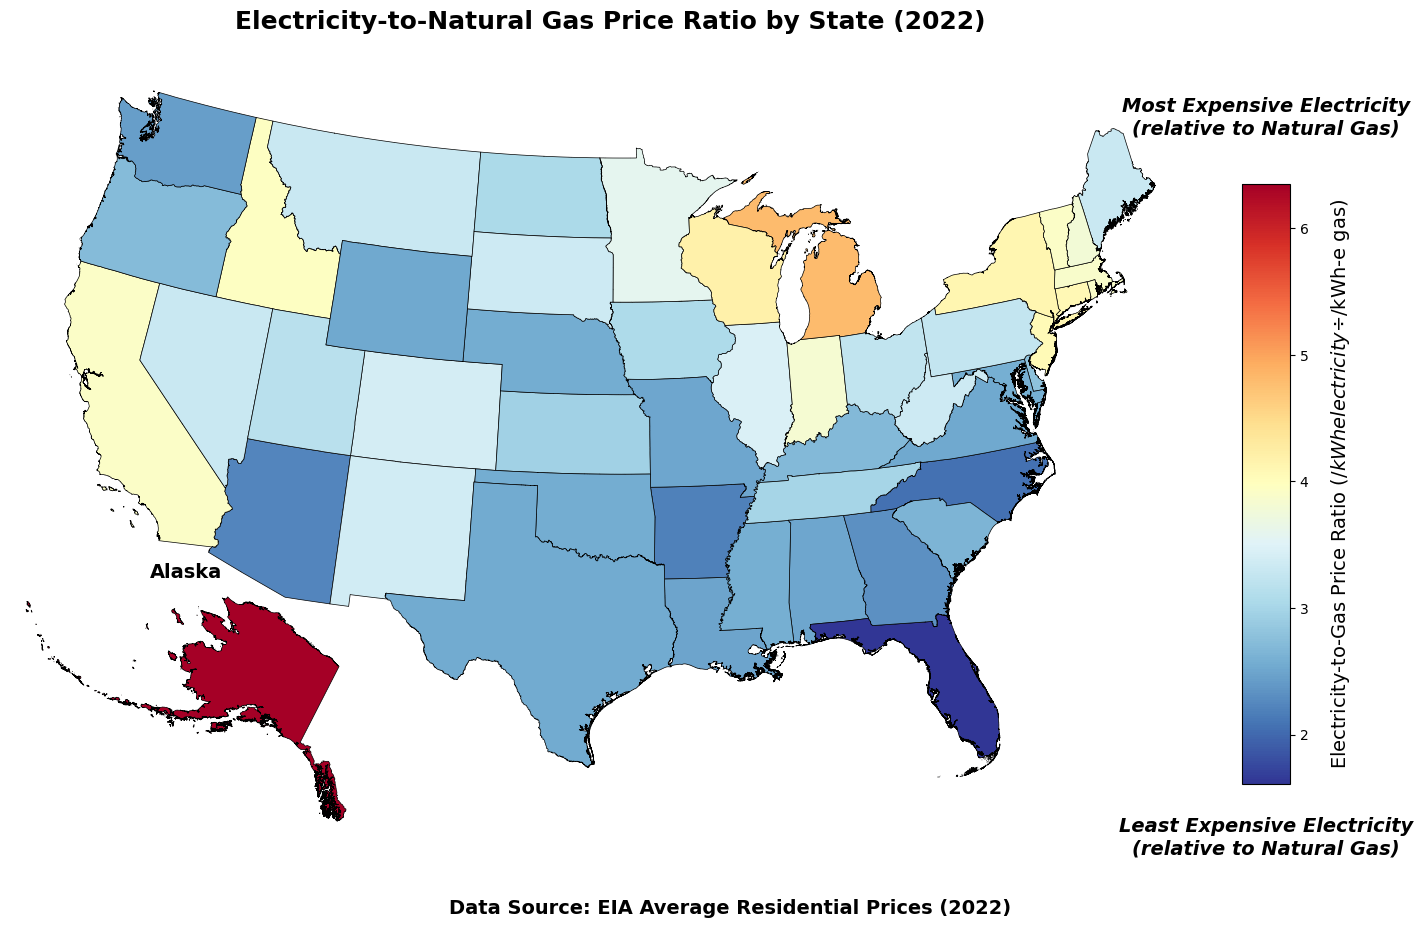


✓ STEP 4 COMPLETE - Map created successfully!


In [13]:
def create_price_ratio_map(
    gdf_conus: gpd.GeoDataFrame,
    gdf_alaska: gpd.GeoDataFrame,
    year: int = 2022,
    output_path: Optional[str] = None,
    figsize: Tuple[int, int] = (16, 10),
    dpi: int = 600,
    cmap: str = 'RdYlBu_r',
    show_plot: bool = True
) -> Optional[str]:
    """
    Create a choropleth map of state-level electricity-to-gas price ratios.
    
    Args:
        gdf_conus: GeoDataFrame with continental US states.
        gdf_alaska: GeoDataFrame with Alaska.
        year: Year for title.
        output_path: Path to save PNG (optional).
        figsize: Figure size in inches.
        dpi: Resolution for saved image.
        cmap: Matplotlib colormap name.
        show_plot: Whether to display the plot.
        
    Returns:
        Output path if saved, None otherwise.
    """
    # Determine color scale range
    all_ratios = pd.concat([gdf_conus['Elec_to_Gas_Ratio'], gdf_alaska['Elec_to_Gas_Ratio']])
    vmin, vmax = all_ratios.min(), all_ratios.max()
    
    # Create figure with space for colorbar
    fig = plt.figure(figsize=figsize, facecolor='white')
    
    # Main map axes (CONUS)
    ax_main = fig.add_axes([0.05, 0.1, 0.75, 0.8])
    
    # Alaska inset axes
    ax_alaska = fig.add_axes([0.05, 0.1, 0.22, 0.25])
    
    # Plot Continental US
    gdf_conus.plot(
        column='Elec_to_Gas_Ratio',
        ax=ax_main,
        cmap=cmap,
        edgecolor='black',
        linewidth=0.5,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )
    ax_main.set_axis_off()
    
    # Add title
    ax_main.set_title(
        f'Electricity-to-Natural Gas Price Ratio by State ({year})',
        fontsize=18,
        fontweight='bold',
        pad=20
    )
    
    # Plot Alaska inset
    gdf_alaska.plot(
        column='Elec_to_Gas_Ratio',
        ax=ax_alaska,
        cmap=cmap,
        edgecolor='black',
        linewidth=0.5,
        vmin=vmin,
        vmax=vmax,
        legend=False
    )
    ax_alaska.set_axis_off()
    ax_alaska.set_title('Alaska', fontsize=14, fontweight='bold')
    
    # Add colorbar
    cax = fig.add_axes([0.82, 0.15, 0.03, 0.6])
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(
        'Electricity-to-Gas Price Ratio ($/kWh electricity ÷ $/kWh-e gas)',
        fontsize=14,
        labelpad=15
    )
    
    # Add interpretation text
    fig.text(
        0.835, 0.80,
        'Most Expensive Electricity\n(relative to Natural Gas)',
        fontsize=14,
        ha='center',
        style='italic',
        fontweight='bold'
    )

    # Add interpretation text
    fig.text(
        0.835, 0.08,
        'Least Expensive Electricity\n(relative to Natural Gas)',
        fontsize=14,
        ha='center',
        style='italic',
        fontweight='bold'
    )

    # Add data source
    fig.text(
        0.5, 0.02,
        'Data Source: EIA Average Residential Prices (2022)',
        fontsize=14,
        ha='center',
        # color='gray',
        fontweight='bold'
    )
    
    # Save if output path provided
    if output_path:
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"✓ Map saved to: {output_path}")
    
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    
    return output_path if output_path else None


# ============================================================================
# CREATE AND DISPLAY MAP
# ============================================================================

print("===== STEP 4: CREATE CHOROPLETH MAP =====")
print("Rendering state-level electricity-to-gas price ratios...\n")

# Create the map
output_file = create_price_ratio_map(
    gdf_conus=gdf_conus,
    gdf_alaska=gdf_alaska,
    year=2022,
    output_path='state_price_ratio_map_2022.png',
    figsize=(16, 10),
    dpi=600,
    cmap='RdYlBu_r',  # Red (high) to Blue (low)
    show_plot=True
)

print("\n✓ STEP 4 COMPLETE - Map created successfully!")

---
# STEP 5: Display Complete Results Table
---

View the complete price ratio data for all states.

In [6]:
print("===== COMPLETE STATE PRICE RATIO TABLE (2022) =====\n")
print("Columns:")
print("  - Elec_Price_per_kWh: Electricity price ($/kWh)")
print("  - NG_Price_per_1000cf: Natural gas price ($/1000 cubic feet)")
print("  - NG_Price_per_kWh: Natural gas price converted to $/kWh equivalent")
print("  - Elec_to_Gas_Ratio: How many times more expensive electricity is vs gas\n")
print("-" * 100)

# Display full table
display(df_ratios)

===== COMPLETE STATE PRICE RATIO TABLE (2022) =====

Columns:
  - Elec_Price_per_kWh: Electricity price ($/kWh)
  - NG_Price_per_1000cf: Natural gas price ($/1000 cubic feet)
  - NG_Price_per_kWh: Natural gas price converted to $/kWh equivalent
  - Elec_to_Gas_Ratio: How many times more expensive electricity is vs gas

----------------------------------------------------------------------------------------------------


,State_Abbr,State_Name,Elec_Price_per_kWh,NG_Price_per_1000cf,NG_Price_per_kWh,Elec_to_Gas_Ratio
0,AK,Alaska,0.2310,11.08,0.0364,6.35
1,MI,Michigan,0.1786,11.31,0.0371,4.81
2,WI,Wisconsin,0.1562,11.34,0.0372,4.19
3,NY,New York,0.2208,16.34,0.0537,4.11
4,CT,Connecticut,0.2461,18.36,0.0603,4.08
5,NJ,New Jersey,0.1674,12.53,0.0411,4.07
6,ID,Idaho,0.1037,7.97,0.0262,3.96
7,CA,California,0.2584,20.15,0.0662,3.91
8,VT,Vermont,0.1993,15.51,0.0509,3.91
9,RI,Rhode Island,0.2321,18.17,0.0597,3.89


---
# Analysis Complete!
---

## Summary

This notebook calculated and visualized the electricity-to-natural gas price ratio across U.S. states for 2022.

**Key Findings:**
- States with **high ratios** (e.g., Alaska, Michigan, Wisconsin): Electricity is relatively expensive compared to gas
- States with **low ratios** (e.g., Florida, North Carolina, Arkansas): Electricity is relatively competitive with gas

**Implications for Heating:**
- In states with lower ratios, electric heat pumps become more economically attractive
- In states with higher ratios, natural gas heating may be more cost-effective
- Heat pump efficiency (COP > 1) can offset higher electricity prices in many cases

## Output Files
- `state_price_ratio_map_2022.png`: Choropleth map visualization

## Further Analysis Ideas
- Compare ratios across multiple years to identify trends
- Factor in heat pump efficiency (COP 2.5-4.0) to calculate true heating cost comparison
- Overlay with heating fuel usage data to explore correlation

---

**Questions?** Review the cell comments or check function docstrings for detailed explanations.